
# Toy LWE 18채널 비밀키 복구 검증 노트북

이 노트북은 `document/idea.md`, `lwe_18channel_implementation_evaluation_plan.md`, 그리고 두 보고서의 결론을 바로 실험 가능한 형태로 묶은 것입니다.

핵심 검증 포인트는 세 가지입니다.

1. **모델은 18개 채널 전체를 입력으로 사용하는가?**  
   입력 텐서는 `X = [B, 18, M, n]`이며, 18개의 A,b-derived feature를 모두 `1x1 Conv` channel mixer에 넣어 계산합니다. 각 채널은 A,b의 원본값, modular 주기성, A-b 관계, 후보값별 compatibility, parity/product류 단서를 서로 다른 관점에서 제공합니다.

2. **Conv를 써도 되는가?**  
   여기서 Conv는 이미지의 3x3 local pattern 추출기가 아닙니다. `1x1 Conv`는 각 `(i,j)` 위치에서 18개 feature를 섞는 선형층이고, `(M,1) Conv`는 한 secret 좌표 j의 M개 방정식 evidence를 하나의 column token으로 압축하는 선형 projection입니다.

3. **정보 손실은 없는가?**  
   feature encoding 단계는 보존적입니다. 하지만 `(M,1) Conv` 이후의 embedding은 일반적으로 압축이므로 lossless가 아닙니다. 그래서 모델은 최종 solver가 아니라 후보 생성기로 보고, 마지막 full-key 판정은 raw A,b를 이용한 residual verifier로 닫아야 합니다.

이 실험은 실제 보안 파라미터 LWE 공격 주장이 아니라, 저차원 toy LWE에서 representation learning이 modular linear relation을 얼마나 잘 잡는지 확인하는 프레임워크입니다.


In [18]:

import os
import math
import itertools
import random
import time
from dataclasses import dataclass
from pathlib import Path

# 홈 디렉터리 쓰기 권한이 없는 환경에서도 matplotlib/IPython이 조용히 동작하도록 프로젝트 내부 cache 사용
PROJECT_ROOT = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
os.environ.setdefault("IPYTHONDIR", str(PROJECT_ROOT / ".cache" / "ipython"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["IPYTHONDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 20260426
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device}, torch={torch.__version__}, cuda_available={torch.cuda.is_available()}")


device=cuda, torch=2.7.0+cu128, cuda_available=True


In [19]:

CLASS_VALUES = torch.tensor([-3, -2, -1, 0, 1, 2, 3], dtype=torch.long)
NONZERO_VALUES = torch.tensor([-3, -2, -1, 1, 2, 3], dtype=torch.long)
CHANNEL_NAMES_18 = [
    "centered_A", "abs_centered_A", "sin_A", "cos_A",
    "centered_b", "abs_centered_b", "centered_A_times_b", "mod_dist_A_b",
    "compat_-3", "compat_-2", "compat_-1", "compat_1", "compat_2", "compat_3",
    "parity_A", "parity_b", "square_A", "product_A_b",
]

@dataclass
class ExperimentConfig:
    name: str
    n: int = 10
    M: int = 64
    q: int = 127
    h: int = 3
    sigma_e: float = 0.0
    in_ch: int = 18
    batch_size: int = 64
    eval_batch_size: int = 64
    epochs: int = 3
    steps_per_epoch: int = 12
    eval_batches: int = 4
    lr: float = 3e-4
    weight_decay: float = 0.03
    hidden_ch: int = 32
    embed_dim: int = 64
    depth: int = 2
    heads: int = 4
    dropout: float = 0.05
    topk: int = 2
    residual_eval_samples: int = 8
    centroid_batches: int = 4
    log_every_steps: int = 250

PROFILES = {
    # 빠른 노트북 검증용. full 학습 결론을 내리는 세팅은 아니고, 전체 파이프라인/로그 검증이 목적입니다.
    "smoke": ExperimentConfig(name="smoke_h3_noiseless", epochs=3, steps_per_epoch=12, batch_size=64),
    # 실제 1차 실험용. GPU가 있으면 먼저 이 정도부터 권장합니다.
    "main": ExperimentConfig(name="main_h3_noiseless", epochs=30, steps_per_epoch=200, batch_size=128, eval_batches=20, hidden_ch=64, embed_dim=128, depth=3),
    # noise curriculum 시작점.
    "noise1": ExperimentConfig(name="noise_h3_sigma1", sigma_e=1.0, epochs=300, steps_per_epoch=3256, batch_size=512, eval_batches=20, hidden_ch=64, embed_dim=128, depth=3),
}

PROFILE = os.environ.get("LWE18_PROFILE", "noise1")
cfg = PROFILES[PROFILE]
print(cfg)
assert cfg.in_ch == 18, f"This notebook is configured for the 18-channel experiment, got in_ch={cfg.in_ch}"
print(f"streamed train samples per run = {cfg.epochs * cfg.steps_per_epoch * cfg.batch_size:,}")


ExperimentConfig(name='noise_h3_sigma1', n=10, M=64, q=127, h=3, sigma_e=1.0, in_ch=18, batch_size=512, eval_batch_size=64, epochs=300, steps_per_epoch=3256, eval_batches=20, lr=0.0003, weight_decay=0.03, hidden_ch=64, embed_dim=128, depth=3, heads=4, dropout=0.05, topk=2, residual_eval_samples=8, centroid_batches=4, log_every_steps=250)
streamed train samples per run = 500,121,600


In [20]:

def centered_int(x: torch.Tensor, q: int) -> torch.Tensor:
    half = q // 2
    return torch.remainder(x + half, q) - half


def centered_float(x: torch.Tensor, q: int) -> torch.Tensor:
    return centered_int(x, q).float() / float(q // 2)


def mod_dist(x: torch.Tensor, y: torch.Tensor, q: int) -> torch.Tensor:
    d = torch.remainder(x - y, q)
    d = torch.minimum(d, q - d)
    return d.float() / (q / 2.0)


def generate_sparse_s(batch_size: int, n: int, h: int, device: torch.device, values=NONZERO_VALUES) -> torch.Tensor:
    """정확히 h개의 nonzero를 갖는 sparse small-integer secret. shape=[B,n]."""
    values = values.to(device)
    s = torch.zeros(batch_size, n, dtype=torch.long, device=device)
    support = torch.rand(batch_size, n, device=device).topk(h, dim=1).indices
    value_idx = torch.randint(0, len(values), (batch_size, h), device=device)
    s.scatter_(1, support, values[value_idx])
    return s


def generate_lwe_batch(batch_size: int, M: int, n: int, q: int, h: int, sigma_e: float, device: torch.device):
    s = generate_sparse_s(batch_size, n, h, device)
    A = torch.randint(0, q, (batch_size, M, n), dtype=torch.long, device=device)
    if sigma_e > 0:
        e = torch.round(torch.randn(batch_size, M, device=device) * sigma_e).long()
    else:
        e = torch.zeros(batch_size, M, dtype=torch.long, device=device)
    prod = torch.bmm(A.float(), s.float().unsqueeze(-1)).squeeze(-1).round().long()
    b = torch.remainder(prod + e, q).unsqueeze(-1)
    return A, b, s, e.unsqueeze(-1)


def encode_lwe_features(A: torch.Tensor, b: torch.Tensor, q: int, channels: int = 18) -> torch.Tensor:
    """A:[B,M,n], b:[B,M,1] -> X:[B,C,M,n]. channels in {3,8,14,18}."""
    B, M, n = A.shape
    b_exp = b.expand(-1, -1, n)
    cA = centered_float(A, q)
    cB = centered_float(b_exp, q)

    if channels == 3:
        out = [cA, cB, mod_dist(A, b_exp, q)]
        return torch.stack(out, dim=1).contiguous()

    out = [
        cA,
        torch.abs(cA),
        torch.sin(2.0 * math.pi * A.float() / q),
        torch.cos(2.0 * math.pi * A.float() / q),
        cB,
        torch.abs(cB),
        cA * cB,
        mod_dist(A, b_exp, q),
    ]
    if channels in (14, 18):
        for v in [-3, -2, -1, 1, 2, 3]:
            out.append(mod_dist(b_exp, torch.remainder(v * A, q), q))
    if channels == 18:
        parity_A = (torch.remainder(A, 2).float() * 2.0) - 1.0
        parity_b = (torch.remainder(b_exp, 2).float() * 2.0) - 1.0
        out.extend([
            parity_A,
            parity_b,
            centered_float(torch.remainder(A * A, q), q),
            centered_float(torch.remainder(A * b_exp, q), q),
        ])
    if len(out) != channels:
        raise ValueError(f"unsupported channel count: {channels}")
    return torch.stack(out, dim=1).contiguous()


def secret_to_label(s: torch.Tensor) -> torch.Tensor:
    return (s + 3).long()


def label_to_secret(label: torch.Tensor) -> torch.Tensor:
    return (label.long() - 3)


In [21]:
def reconstruct_A_b_from_18ch(X: torch.Tensor, q: int):
    """18채널 텐서 안에 raw A,b가 보존되는지 보는 보조 sanity check다.

    모델은 18개 채널 전체를 사용한다. 이 함수는 18채널 중 원본 A,b를 담는
    canonical channel로 역복원이 가능한지만 확인한다.
    """
    half = q // 2
    A_centered = torch.round(X[:, 0] * half).long()
    b_centered = torch.round(X[:, 4, :, 0] * half).long().unsqueeze(-1)
    A_hat = torch.remainder(A_centered, q)
    b_hat = torch.remainder(b_centered, q)
    return A_hat, b_hat


@torch.no_grad()
def verify_18ch_encoding_consistency(q=127):
    """raw A,b 보존과 18개 파생 채널 전체의 self-consistency를 같이 검증한다."""
    A, b, s, e = generate_lwe_batch(batch_size=16, M=17, n=9, q=q, h=3, sigma_e=1.0, device=device)
    X = encode_lwe_features(A, b, q, channels=18)
    assert X.shape[1] == 18, f"expected 18 channels, got {X.shape[1]}"

    A_hat, b_hat = reconstruct_A_b_from_18ch(X, q)
    assert torch.equal(A, A_hat), "A reconstruction failed"
    assert torch.equal(b, b_hat), "b reconstruction failed"

    # 복원한 raw A,b로 18채널을 다시 만들었을 때 원래 X와 같아야 한다.
    X_recomputed = encode_lwe_features(A_hat, b_hat, q, channels=18)
    per_channel_max_err = (X - X_recomputed).abs().amax(dim=(0, 2, 3)).detach().cpu()
    assert float(per_channel_max_err.max()) < 1e-6, "18-channel recomputation mismatch"

    return X.shape, per_channel_max_err


def verify_conv_equivalences():
    """Conv가 여기서는 Linear projection과 같은 연산임을 수치적으로 검증한다.

    CUDA/TF32는 Linear와 Conv의 저수준 kernel이 달라 1e-4 수준 차이가 보일 수 있다.
    수학적 등가성 검증은 CPU float64에서 수행한다.
    """
    test_device = torch.device("cpu")
    dtype = torch.float64

    # 1x1 Conv == 각 위치의 channel vector에 동일한 Linear 적용
    B, C, M, n, H = 2, 18, 5, 4, 7
    x = torch.randn(B, C, M, n, device=test_device, dtype=dtype)
    conv1 = nn.Conv2d(C, H, kernel_size=1, dtype=dtype).to(test_device)
    linear1 = nn.Linear(C, H, dtype=dtype).to(test_device)
    with torch.no_grad():
        linear1.weight.copy_(conv1.weight[:, :, 0, 0])
        linear1.bias.copy_(conv1.bias)
    y_conv = conv1(x).permute(0, 2, 3, 1)
    y_lin = linear1(x.permute(0, 2, 3, 1))
    err_1x1 = (y_conv - y_lin).abs().max().item()

    # (M,1) Conv == 각 column j의 [hidden_ch, M] evidence를 Linear projection
    B, hidden, M, n, E = 2, 5, 7, 4, 6
    z = torch.randn(B, hidden, M, n, device=test_device, dtype=dtype)
    conv_col = nn.Conv2d(hidden, E, kernel_size=(M, 1), dtype=dtype).to(test_device)
    linear_col = nn.Linear(hidden * M, E, dtype=dtype).to(test_device)
    with torch.no_grad():
        linear_col.weight.copy_(conv_col.weight.squeeze(-1).reshape(E, hidden * M))
        linear_col.bias.copy_(conv_col.bias)
    y_conv = conv_col(z).squeeze(2).transpose(1, 2).reshape(B * n, E)
    flat = z.permute(0, 3, 1, 2).reshape(B * n, hidden * M)
    y_lin = linear_col(flat)
    err_col = (y_conv - y_lin).abs().max().item()
    return err_1x1, err_col

shape, ch_err = verify_18ch_encoding_consistency(cfg.q)
err_1x1, err_col = verify_conv_equivalences()
print(f"18ch encoding preserves raw A,b: OK, X shape={shape}")
print(f"18ch recomputation max error     : {float(ch_err.max()):.3e}")
print(f"1x1 Conv vs Linear max error     : {err_1x1:.3e}")
print(f"(M,1) Conv vs Linear max error   : {err_col:.3e}")
print("주의: 모델은 18채널 전체를 입력으로 사용합니다. A,b 복원은 정보 보존 sanity check이고, Conv projection 이후는 일반적으로 압축이라 lossless가 아닙니다.")

18ch encoding preserves raw A,b: OK, X shape=torch.Size([16, 18, 17, 9])
18ch recomputation max error     : 0.000e+00
1x1 Conv vs Linear max error     : 3.331e-16
(M,1) Conv vs Linear max error   : 4.441e-16
주의: 모델은 18채널 전체를 입력으로 사용합니다. A,b 복원은 정보 보존 sanity check이고, Conv projection 이후는 일반적으로 압축이라 lossless가 아닙니다.


In [22]:

A_dbg, b_dbg, s_dbg, e_dbg = generate_lwe_batch(
    batch_size=3, M=cfg.M, n=cfg.n, q=cfg.q, h=cfg.h, sigma_e=cfg.sigma_e, device=device
)
X_dbg = encode_lwe_features(A_dbg, b_dbg, cfg.q, channels=cfg.in_ch)

print("Raw secret s samples (비밀키 원본 표시):")
display(pd.DataFrame(s_dbg.cpu().numpy(), columns=[f"s{j}" for j in range(cfg.n)]))

print("A[0] first 8 equations:")
display(pd.DataFrame(A_dbg[0, :8].cpu().numpy(), columns=[f"A_col{j}" for j in range(cfg.n)]))

print("b[0] first 16 values and e[0] first 16 values:")
display(pd.DataFrame({
    "b": b_dbg[0, :16, 0].cpu().numpy(),
    "e": e_dbg[0, :16, 0].cpu().numpy(),
}))

stats = []
for c in range(cfg.in_ch):
    xc = X_dbg[:, c]
    stats.append({"channel": CHANNEL_NAMES_18[c] if cfg.in_ch == 18 else f"ch{c}",
                  "min": float(xc.min().cpu()), "max": float(xc.max().cpu()), "mean": float(xc.mean().cpu())})
print(f"Encoded X shape: {tuple(X_dbg.shape)}")
display(pd.DataFrame(stats))


Raw secret s samples (비밀키 원본 표시):


,s0,s1,s2,s3,s4,s5,s6,s7,s8,s9
0,0,0,0,0,0,1,-3,2,0,0
1,0,3,0,0,1,0,3,0,0,0
2,0,0,0,-1,0,0,0,2,-3,0


A[0] first 8 equations:


,A_col0,A_col1,A_col2,A_col3,A_col4,A_col5,A_col6,A_col7,A_col8,A_col9
0,20,37,28,76,101,84,46,5,8,38
1,42,15,36,45,118,61,6,20,80,8
2,34,91,17,111,89,13,101,115,113,36
3,42,58,79,84,18,73,124,45,99,110
4,41,63,80,42,92,68,119,114,62,14
5,105,89,54,10,71,106,8,78,113,30
6,8,40,82,36,97,117,47,53,29,109
7,51,58,45,12,79,87,2,78,54,115


b[0] first 16 values and e[0] first 16 values:


,b,e
0,82,-1
1,83,0
2,66,-1
3,44,-1
4,66,0
5,112,1
6,82,0
7,109,-1
8,59,0
9,7,0


Encoded X shape: (3, 18, 64, 10)


,channel,min,max,mean
0,centered_A,-1.000000,1.000000,0.006630
1,abs_centered_A,0.000000,1.000000,0.505605
2,sin_A,-0.999924,0.999924,0.015803
3,cos_A,-0.999694,1.000000,-0.004640
4,centered_b,-1.000000,1.000000,0.010086
5,abs_centered_b,0.015873,1.000000,0.521495
6,centered_A_times_b,-0.984127,0.968254,-0.003426
7,mod_dist_A_b,0.000000,0.992126,0.514493
8,compat_-3,0.000000,0.992126,0.506734
9,compat_-2,0.000000,0.992126,0.505094


In [23]:

def make_sparse_candidate_table(n: int, h: int, values=NONZERO_VALUES, device=device) -> torch.Tensor:
    """정확한 h-sparse 후보 전체. n=10,h=3이면 C(10,3)*6^3=25,920개."""
    values_list = [int(v) for v in values.cpu().tolist()]
    supports = list(itertools.combinations(range(n), h))
    value_products = list(itertools.product(values_list, repeat=h))
    candidates = torch.zeros(len(supports) * len(value_products), n, dtype=torch.long)
    row = 0
    for supp in supports:
        supp = list(supp)
        for vals in value_products:
            candidates[row, supp] = torch.tensor(vals, dtype=torch.long)
            row += 1
    return candidates.to(device)


def residual_score_for_candidates(A_one: torch.Tensor, b_one: torch.Tensor, candidates: torch.Tensor, q: int, chunk_size: int = 8192):
    best_score = None
    best_s = None
    b_vec = b_one.squeeze(-1)
    for cand in candidates.split(chunk_size):
        pred_b = torch.remainder((cand.float() @ A_one.float().T).round().long(), q)
        r = centered_int(b_vec.unsqueeze(0) - pred_b, q)
        scores = (r.float() ** 2).mean(dim=1)
        local_idx = torch.argmin(scores)
        local_score = scores[local_idx]
        if best_score is None or local_score < best_score:
            best_score = local_score
            best_s = cand[local_idx].clone()
    return best_s, best_score

# residual verifier 자체가 toy noiseless setting에서 수학적으로 닫히는지 확인
cand_table = make_sparse_candidate_table(cfg.n, cfg.h, device=device)
A_check, b_check, s_check, _ = generate_lwe_batch(4, cfg.M, cfg.n, cfg.q, cfg.h, sigma_e=0.0, device=device)
rows = []
for i in range(A_check.shape[0]):
    best_s, best_score = residual_score_for_candidates(A_check[i], b_check[i], cand_table, cfg.q)
    rows.append({
        "sample": i,
        "true_s": s_check[i].cpu().tolist(),
        "best_s": best_s.cpu().tolist(),
        "exact": bool(torch.equal(best_s, s_check[i])),
        "residual_score": float(best_score.cpu()),
    })
print(f"global h-sparse residual candidate count = {len(cand_table):,}")
display(pd.DataFrame(rows))


global h-sparse residual candidate count = 25,920


,sample,true_s,best_s,exact,residual_score
0,0,"[0, 0, 0, 0, -2, 0, -2, 0, -2, 0]","[0, 0, 0, 0, -2, 0, -2, 0, -2, 0]",True,0.0
1,1,"[-3, 0, 0, 1, 0, 0, 0, 0, -2, 0]","[-3, 0, 0, 1, 0, 0, 0, 0, -2, 0]",True,0.0
2,2,"[-2, 3, 0, 0, 0, 0, 0, 0, 0, 2]","[-2, 3, 0, 0, 0, 0, 0, 0, 0, 2]",True,0.0
3,3,"[0, -2, 0, 0, -3, 1, 0, 0, 0, 0]","[0, -2, 0, 0, -3, 1, 0, 0, 0, 0]",True,0.0


In [24]:

class LWEColumnTransformer(nn.Module):
    def __init__(self, M, n, in_ch=18, hidden_ch=64, embed_dim=128, heads=4, depth=3, dropout=0.1):
        super().__init__()
        self.M = M
        self.n = n
        self.embed_dim = embed_dim
        self.in_ch = in_ch
        self.channel_mixer = nn.Sequential(
            nn.Conv2d(in_ch, hidden_ch, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(hidden_ch, hidden_ch, kernel_size=1),
            nn.GELU(),
        )
        self.patch_embed = nn.Conv2d(hidden_ch, embed_dim, kernel_size=(M, 1))
        self.pos_embed = nn.Parameter(torch.randn(1, n, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.classifier = nn.Linear(embed_dim, 7)

    def forward(self, x, return_embedding=False):
        if x.size(1) != self.in_ch:
            raise ValueError(f"expected {self.in_ch} input channels, got {x.size(1)}")
        z = self.channel_mixer(x)
        z = self.patch_embed(z)              # [B,E,1,n]
        z = z.squeeze(2).transpose(1, 2)     # [B,n,E]
        z = self.norm(z + self.pos_embed)
        z = self.transformer(z)
        logits = self.classifier(z)
        if return_embedding:
            return logits, z
        return logits


def class_weights(device):
    return torch.tensor([5.0, 5.0, 5.0, 1.0, 5.0, 5.0, 5.0], device=device)

model = LWEColumnTransformer(
    M=cfg.M, n=cfg.n, in_ch=cfg.in_ch, hidden_ch=cfg.hidden_ch,
    embed_dim=cfg.embed_dim, heads=cfg.heads, depth=cfg.depth, dropout=cfg.dropout,
).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"parameters={num_params:,}")
print(f"first_conv_weight_shape={tuple(model.channel_mixer[0].weight.shape)}  # [hidden_ch, 18, 1, 1]")


LWEColumnTransformer(
  (channel_mixer): Sequential(
    (0): Conv2d(18, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (3): GELU(approximate='none')
  )
  (patch_embed): Conv2d(64, 128, kernel_size=(64, 1), stride=(1, 1))
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.05, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.

/home/yu_mcc/miniconda3/envs/lattice_env/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [25]:

def residual_score_batch(A: torch.Tensor, b: torch.Tensor, s_hat: torch.Tensor, q: int) -> torch.Tensor:
    pred_raw = torch.bmm(A.float(), s_hat.float().unsqueeze(-1)).squeeze(-1).round().long()
    pred_b = torch.remainder(pred_raw, q)
    r = centered_int(b.squeeze(-1) - pred_b, q)
    return (r.float() ** 2).mean(dim=1)


def compute_metrics_from_prediction(pred_s: torch.Tensor, true_s: torch.Tensor, A: torch.Tensor, b: torch.Tensor, q: int):
    eps = 1e-8
    pred_support = pred_s != 0
    true_support = true_s != 0
    tp = (pred_support & true_support).float().sum()
    fp = (pred_support & ~true_support).float().sum()
    fn = (~pred_support & true_support).float().sum()
    true_nonzero = true_support
    if true_nonzero.any():
        sign_acc = (torch.sign(pred_s[true_nonzero].float()) == torch.sign(true_s[true_nonzero].float())).float().mean()
        mag_acc = (torch.abs(pred_s[true_nonzero]) == torch.abs(true_s[true_nonzero])).float().mean()
    else:
        sign_acc = torch.tensor(0.0, device=pred_s.device)
        mag_acc = torch.tensor(0.0, device=pred_s.device)
    return {
        "coord_acc": (pred_s == true_s).float().mean().item(),
        "support_acc": (pred_support == true_support).float().mean().item(),
        "nonzero_precision": (tp / (tp + fp + eps)).item(),
        "nonzero_recall": (tp / (tp + fn + eps)).item(),
        "sign_acc": sign_acc.item(),
        "mag_acc": mag_acc.item(),
        "full_match": (pred_s == true_s).all(dim=1).float().mean().item(),
        "residual_score": residual_score_batch(A, b, pred_s, q).mean().item(),
    }


def topk_metrics(logits: torch.Tensor, labels: torch.Tensor, k: int):
    topk_labels = torch.topk(torch.softmax(logits, dim=-1), k=k, dim=-1).indices
    hit_per_coord = (topk_labels == labels.unsqueeze(-1)).any(dim=-1)
    return {
        f"top{k}_coord_hit": hit_per_coord.float().mean().item(),
        f"top{k}_full_candidate_hit": hit_per_coord.all(dim=1).float().mean().item(),
    }


def enumerate_topk_candidates_one(topk_values_one: torch.Tensor) -> torch.Tensor:
    choices = []
    for j in range(topk_values_one.shape[0]):
        vals = torch.unique(topk_values_one[j].long()).cpu().tolist()
        choices.append(vals)
    combos = list(itertools.product(*choices))
    return torch.tensor(combos, dtype=torch.long, device=topk_values_one.device)


@torch.no_grad()
def predict_with_topk_residual(model, A: torch.Tensor, b: torch.Tensor, q: int, k: int = 2, max_samples: int = 8):
    model.eval()
    X = encode_lwe_features(A, b, q, channels=cfg.in_ch)
    logits = model(X)
    topk_labels = torch.topk(torch.softmax(logits, dim=-1), k=k, dim=-1).indices
    topk_values = label_to_secret(topk_labels)
    preds = []
    limit = min(A.shape[0], max_samples)
    for i in range(limit):
        candidates = enumerate_topk_candidates_one(topk_values[i])
        best_s, _ = residual_score_for_candidates(A[i], b[i], candidates, q)
        preds.append(best_s)
    return torch.stack(preds, dim=0)


run_dir=/home/yu_mcc/vit_PQC/notebooks/runs/noise_h3_sigma1_20260426_183047
history_csv=/home/yu_mcc/vit_PQC/notebooks/runs/noise_h3_sigma1_20260426_183047/history.csv
config=ExperimentConfig(name='noise_h3_sigma1', n=10, M=64, q=127, h=3, sigma_e=1.0, in_ch=18, batch_size=512, eval_batch_size=64, epochs=300, steps_per_epoch=3256, eval_batches=20, lr=0.0003, weight_decay=0.03, hidden_ch=64, embed_dim=128, depth=3, heads=4, dropout=0.05, topk=2, residual_eval_samples=8, centroid_batches=4, log_every_steps=250)
streamed_train_samples=500,121,600
epoch 001 step 00250/3256 | samples=128,000/1,667,072 | recent_loss=1.8722 | recent_coord=0.690 | recent_full=0.000 | epoch_elapsed=6.0s
epoch 001 step 00500/3256 | samples=256,000/1,667,072 | recent_loss=1.8490 | recent_coord=0.700 | recent_full=0.000 | epoch_elapsed=12.1s
epoch 001 step 00750/3256 | samples=384,000/1,667,072 | recent_loss=1.8483 | recent_coord=0.700 | recent_full=0.000 | epoch_elapsed=18.0s
epoch 001 step 01000/3256 | samples=5

,epoch,train_loss,train_coord_acc,train_full_match,val_coord_acc,val_support_acc,val_nonzero_precision,val_nonzero_recall,val_sign_acc,val_mag_acc,val_full_match,val_residual_score,val_top2_coord_hit,val_top2_full_candidate_hit
0,1,1.849826,0.699241,0.0,0.7,0.7,0.0,0.0,0.0,0.0,0.0,1346.467822,0.750000,0.003906
1,2,1.847485,0.700000,0.0,0.7,0.7,0.0,0.0,0.0,0.0,0.0,1340.122058,0.751172,0.006250
2,3,1.847353,0.700000,0.0,0.7,0.7,0.0,0.0,0.0,0.0,0.0,1343.396899,0.746563,0.004687
3,4,1.847278,0.700000,0.0,0.7,0.7,0.0,0.0,0.0,0.0,0.0,1346.452454,0.750547,0.005469
4,5,1.847234,0.700000,0.0,0.7,0.7,0.0,0.0,0.0,0.0,0.0,1338.465271,0.749922,0.004687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,1.847155,0.700000,0.0,0.7,0.7,0.0,0.0,0.0,0.0,0.0,1343.842444,0.753750,0.005469
296,297,1.847155,0.700000,0.0,0.7,0.7,0.0,0.0,0.0,0.0,0.0,1336.642224,0.749766,0.005469
297,298,1.847155,0.700000,0.0,0.7,0.7,0.0,0.0,0.0,0.0,0.0,1346.731311,0.748984,0.003906
298,299,1.847155,0.700000,0.0,0.7,0.7,0.0,0.0,0.0,0.0,0.0,1341.677820,0.751563,0.007031


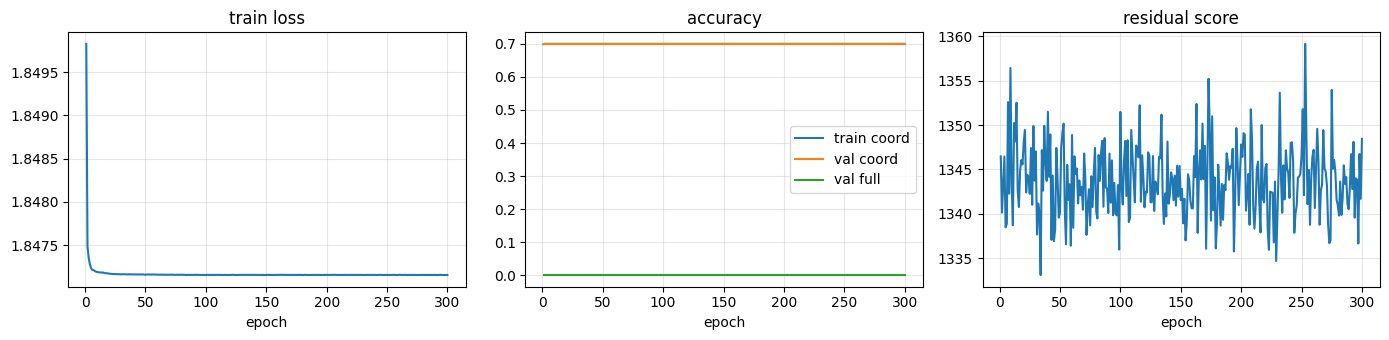

In [26]:
@torch.no_grad()
def evaluate_model(model, cfg: ExperimentConfig, num_batches=None):
    model.eval()
    num_batches = cfg.eval_batches if num_batches is None else num_batches
    metric_rows = []
    for _ in range(num_batches):
        A, b, s, e = generate_lwe_batch(cfg.eval_batch_size, cfg.M, cfg.n, cfg.q, cfg.h, cfg.sigma_e, device)
        X = encode_lwe_features(A, b, cfg.q, channels=cfg.in_ch)
        labels = secret_to_label(s)
        logits = model(X)
        pred_s = label_to_secret(torch.argmax(logits, dim=-1))
        row = compute_metrics_from_prediction(pred_s, s, A, b, cfg.q)
        row.update(topk_metrics(logits, labels, cfg.topk))
        metric_rows.append(row)
    return pd.DataFrame(metric_rows).mean().to_dict()


def train_one_epoch(model, optimizer, criterion, cfg: ExperimentConfig, epoch: int, log_fn=None):
    model.train()
    losses = []
    coord_accs = []
    full_matches = []
    epoch_t0 = time.time()
    log_every = max(1, int(cfg.log_every_steps))

    for step in range(1, cfg.steps_per_epoch + 1):
        A, b, s, e = generate_lwe_batch(cfg.batch_size, cfg.M, cfg.n, cfg.q, cfg.h, cfg.sigma_e, device)
        X = encode_lwe_features(A, b, cfg.q, channels=cfg.in_ch)
        labels = secret_to_label(s)
        logits = model(X)
        loss = criterion(logits.reshape(-1, 7), labels.reshape(-1))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            pred_s = label_to_secret(torch.argmax(logits, dim=-1))
            losses.append(loss.item())
            coord_accs.append((pred_s == s).float().mean().item())
            full_matches.append((pred_s == s).all(dim=1).float().mean().item())

        if log_fn is not None and (step % log_every == 0 or step == cfg.steps_per_epoch):
            recent = min(log_every, len(losses))
            seen = step * cfg.batch_size
            total = cfg.steps_per_epoch * cfg.batch_size
            msg = (
                f"epoch {epoch:03d} step {step:05d}/{cfg.steps_per_epoch} | "
                f"samples={seen:,}/{total:,} | "
                f"recent_loss={float(np.mean(losses[-recent:])):.4f} | "
                f"recent_coord={float(np.mean(coord_accs[-recent:])):.3f} | "
                f"recent_full={float(np.mean(full_matches[-recent:])):.3f} | "
                f"epoch_elapsed={time.time() - epoch_t0:.1f}s"
            )
            log_fn(msg)

    return {
        "train_loss": float(np.mean(losses)),
        "train_coord_acc": float(np.mean(coord_accs)),
        "train_full_match": float(np.mean(full_matches)),
    }


optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
criterion = nn.CrossEntropyLoss(weight=class_weights(device))

run_stamp = time.strftime("%Y%m%d_%H%M%S")
run_dir = PROJECT_ROOT / "runs" / f"{cfg.name}_{run_stamp}"
run_dir.mkdir(parents=True, exist_ok=True)
log_path = run_dir / "train.log"
history_path = run_dir / "history.csv"


def log_line(msg: str):
    print(msg, flush=True)
    with log_path.open("a", encoding="utf-8") as f:
        f.write(msg + "\n")
        f.flush()


history = []
t0 = time.time()
log_line(f"run_dir={run_dir}")
log_line(f"history_csv={history_path}")
log_line(f"config={cfg}")
log_line(f"streamed_train_samples={cfg.epochs * cfg.steps_per_epoch * cfg.batch_size:,}")

for epoch in range(1, cfg.epochs + 1):
    train_log = train_one_epoch(model, optimizer, criterion, cfg, epoch=epoch, log_fn=log_line)
    val_log = evaluate_model(model, cfg)
    row = {"epoch": epoch, **train_log, **{f"val_{k}": v for k, v in val_log.items()}}
    history.append(row)

    hist = pd.DataFrame(history)
    hist.to_csv(history_path, index=False)

    line = (
        f"epoch {epoch:03d} done | loss={row['train_loss']:.4f} | "
        f"train_coord={row['train_coord_acc']:.3f} | val_coord={row['val_coord_acc']:.3f} | "
        f"val_support_recall={row['val_nonzero_recall']:.3f} | val_full={row['val_full_match']:.3f} | "
        f"val_top{cfg.topk}_full_hit={row[f'val_top{cfg.topk}_full_candidate_hit']:.3f} | "
        f"residual={row['val_residual_score']:.2f} | elapsed={time.time() - t0:.1f}s"
    )
    log_line(line)

log_line(f"elapsed_sec={time.time() - t0:.1f}")
log_line(f"final_history_csv={history_path}")

hist = pd.DataFrame(history)
display(hist)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(hist["epoch"], hist["train_loss"])
axes[0].set_title("train loss")
axes[0].set_xlabel("epoch")
axes[0].grid(True, alpha=0.3)
axes[1].plot(hist["epoch"], hist["train_coord_acc"], label="train coord")
axes[1].plot(hist["epoch"], hist["val_coord_acc"], label="val coord")
axes[1].plot(hist["epoch"], hist["val_full_match"], label="val full")
axes[1].set_title("accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].plot(hist["epoch"], hist["val_residual_score"])
axes[2].set_title("residual score")
axes[2].set_xlabel("epoch")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:

@torch.no_grad()
def compute_centroids(model, cfg: ExperimentConfig, num_batches: int):
    model.eval()
    sums = torch.zeros(7, cfg.embed_dim, device=device)
    counts = torch.zeros(7, device=device)
    for _ in range(num_batches):
        A, b, s, e = generate_lwe_batch(cfg.eval_batch_size, cfg.M, cfg.n, cfg.q, cfg.h, cfg.sigma_e, device)
        X = encode_lwe_features(A, b, cfg.q, channels=cfg.in_ch)
        labels = secret_to_label(s)
        _, Z = model(X, return_embedding=True)
        for c in range(7):
            mask = labels == c
            if mask.any():
                sums[c] += Z[mask].sum(dim=0)
                counts[c] += mask.sum()
    return sums / counts.clamp_min(1).unsqueeze(1), counts


@torch.no_grad()
def evaluate_centroid(model, cfg: ExperimentConfig, centroids: torch.Tensor, num_batches: int = 4):
    rows = []
    for _ in range(num_batches):
        A, b, s, e = generate_lwe_batch(cfg.eval_batch_size, cfg.M, cfg.n, cfg.q, cfg.h, cfg.sigma_e, device)
        X = encode_lwe_features(A, b, cfg.q, channels=cfg.in_ch)
        _, Z = model(X, return_embedding=True)
        dist = torch.cdist(Z, centroids.unsqueeze(0).expand(Z.shape[0], -1, -1))
        pred_s = label_to_secret(torch.argmin(dist, dim=-1))
        rows.append(compute_metrics_from_prediction(pred_s, s, A, b, cfg.q))
    return pd.DataFrame(rows).mean().to_dict()

centroids, centroid_counts = compute_centroids(model, cfg, cfg.centroid_batches)
centroid_metrics = evaluate_centroid(model, cfg, centroids, num_batches=max(2, cfg.eval_batches // 2))
print("centroid class counts:", centroid_counts.long().cpu().tolist())
print("centroid metrics:")
display(pd.DataFrame([centroid_metrics]))

# 모델 후보 + residual reranking. smoke에서는 모델이 아직 약할 수 있으므로 top-k 후보 hit와 함께 해석합니다.
A_r, b_r, s_r, _ = generate_lwe_batch(cfg.eval_batch_size, cfg.M, cfg.n, cfg.q, cfg.h, cfg.sigma_e, device)
with torch.no_grad():
    X_r = encode_lwe_features(A_r, b_r, cfg.q, channels=cfg.in_ch)
    logits_r = model(X_r)
    labels_r = secret_to_label(s_r)
    print("top-k candidate coverage:", topk_metrics(logits_r, labels_r, cfg.topk))
    pred_resid = predict_with_topk_residual(model, A_r, b_r, cfg.q, k=cfg.topk, max_samples=cfg.residual_eval_samples)
    true_subset = s_r[:pred_resid.shape[0]]
    residual_rows = []
    for i in range(pred_resid.shape[0]):
        residual_rows.append({
            "sample": i,
            "true_s": true_subset[i].cpu().tolist(),
            "topk_residual_s": pred_resid[i].cpu().tolist(),
            "exact": bool(torch.equal(pred_resid[i], true_subset[i])),
            "score": float(residual_score_batch(A_r[i:i+1], b_r[i:i+1], pred_resid[i:i+1], cfg.q).cpu().item()),
        })
    display(pd.DataFrame(residual_rows))


centroid class counts: [128, 131, 131, 1792, 128, 126, 124]
centroid metrics:


,coord_acc,support_acc,nonzero_precision,nonzero_recall,sign_acc,mag_acc,full_match,residual_score
0,0.057188,0.303438,0.299906,0.990625,0.466146,0.356771,0.0,1335.458594


top-k candidate coverage: {'top2_coord_hit': 0.7593750357627869, 'top2_full_candidate_hit': 0.015625}


,sample,true_s,topk_residual_s,exact,score
0,0,"[2, 0, 0, 0, 1, 0, -3, 0, 0, 0]","[0, -2, 0, 0, -2, -2, 0, -2, -2, 0]",False,875.921875
1,1,"[0, 0, -2, 0, 3, 0, 0, 0, 0, 1]","[-2, 0, -2, 0, -2, 0, -2, 0, 0, -2]",False,932.109375
2,2,"[0, 0, 0, 0, 2, -2, -2, 0, 0, 0]","[0, 0, -2, 0, 0, 0, -2, 0, 0, -2]",False,869.656250
3,3,"[0, -3, 0, 0, 0, 2, 3, 0, 0, 0]","[0, 0, -2, 0, 0, 0, -2, 0, -2, 0]",False,934.015625
4,4,"[-3, 0, 0, 0, 0, 1, 2, 0, 0, 0]","[-2, 0, 0, 0, -2, 0, -2, -2, -2, 0]",False,939.796875
5,5,"[0, 0, 0, 0, -1, 3, 0, 1, 0, 0]","[-2, 0, -2, 0, -2, 0, 0, -2, -2, -2]",False,884.421875
6,6,"[0, 0, 0, 0, -2, 0, 0, 1, 0, -2]","[0, 0, 0, 0, -2, -2, 0, 0, 0, 0]",False,912.625000
7,7,"[0, 0, 0, 0, 2, 0, -3, 0, -3, 0]","[-2, -2, 0, -2, 0, 0, -2, 0, 0, -2]",False,809.359375



## 해석 체크리스트

- **18채널 가능성**: toy setting에서는 가능성이 있습니다. 다만 compat 채널 `d_q(b_i, v A_ij)`는 `s_j=v`의 완전한 likelihood가 아닙니다. 다른 좌표의 기여 `sum_{k!=j} A_ik s_k`가 섞여 있으므로 힌트로만 봐야 합니다.
- **18채널 사용과 정보 보존**: 모델 입력은 항상 `X=[B,18,M,n]`이며 `Conv2d(18, hidden_ch, 1)`가 18개 채널 전체를 동시에 섞습니다. 별도의 A,b 복원 검사는 raw 정보가 encoding 안에 남아 있는지 보는 sanity check일 뿐, 모델이 일부 채널만 쓴다는 뜻이 아닙니다.
- **Conv 사용 정당성**: `1x1 Conv`와 `(M,1) Conv`는 각각 per-cell linear mixing, per-column linear projection과 동치입니다. 자연 이미지식 3x3 Conv를 쓰는 것과 다릅니다.
- **Conv 이후 lossless 여부**: 일반적으로 아닙니다. embedding 차원으로 압축하기 때문에 정보 이론적으로는 손실이 생길 수 있습니다. 그래서 학습 모델은 candidate generator로 쓰고, final decision은 raw A,b residual verifier로 검증해야 합니다.
- **실험 로그**: coordinate accuracy보다 full-key exact match, top-k full candidate hit, residual score를 우선 지표로 봅니다.
- **샘플 수/메모리**: 데이터셋을 저장하지 않고 매 step 새 batch를 생성하는 streaming 방식입니다. `main` profile은 샘플 수를 늘리되 메모리 사용은 batch 단위로 제한합니다.

실제 장시간 실험은 터미널에서 다음처럼 실행하면 됩니다.

```bash
source .venv_lwe18/bin/activate
LWE18_PROFILE=main jupyter nbconvert --execute --to notebook --inplace notebooks/lwe_18ch_full_recovery_experiment.ipynb
```
